<hr>

# ℹ️ DATA COLLECTION


<style>
h1 {
    text-align: left;
    color: blue;
    font-weight: bold;
}

</style>
<hr>

```text
DATA COLLECTION Steps:

0) Data Browsing - using data sources:
- https://opendata.paris.fr/pages/home/
- https://data.iledefrance.fr/pages/home-open-data/
- https://data.gov.uk/ (not using it because i wanna focus on the French market)

1) Data Loading (.txt and .json to .csv and merge if multiple sources)

2) Data Exploration (understand data and take notes)

3) Data Selection (select columns to use or keep or not keep)

4) Data Validation (get sabina to validate the one merged dataset)

```

<style>
h3 {
    margin-top: 0px;
    margin-bottom: 0px;
    font-weight: bold;
}
</style>

### 📂 IMPORTs

In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200) # to display all columns in the dataframe

<hr>

## 1 - DATA DOWNLOADING


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

In [ ]:

# dictionary for Raw data downloadable links 
links = {
    "arrondissements": "https://drive.google.com/uc?export=download&id=1bSUODphKIH01iwxVll5mBqyXaRuHbkGN",
    "communes": "https://drive.google.com/uc?export=download&id=1RVVusBovovbjQnPLgeDEbpzu-1Whakx4",
    "residences-universitaires": "https://drive.google.com/uc?export=download&id=1WUacgZI2yIrLcuKVfVmXRU7SHbtW-QEb",
    "statuts-doccupation-des-residences-principales": "https://drive.google.com/uc?export=download&id=18oD7xM4RYKH4tI4w4fkLle5VFPDITYrvink",
    "lignes-de-transport-en-commun": "https://drive.google.com/uc?export=download&id=1DKSyojyZvjG9YeJBNbxpIq2oVpSUa_kX",
    "ValeursFoncieres-2020-S2": "https://drive.google.com/uc?export=download&id=1pZvuYyOKn1OuCnTMC6WnqpBt1VgMdeh5",    
    "ValeursFoncieres-2021": "https://drive.google.com/uc?export=download&id=1q_gW41roBD641jtboYa1L14MlRqBolcj",    
    "ValeursFoncieres-2022": "https://drive.google.com/uc?export=download&id=1gLxo0Og5ugIfGMqyUeFfnU7mhZ_MX_tG",    
    "ValeursFoncieres-2023": "https://drive.google.com/uc?export=download&id=1K0kFXN_zpsugh5QysLQJoOj5Zbkb4vWA",    
    "ValeursFoncieres-2024": "https://drive.google.com/uc?export=download&id=1x1wpgIchhRViyD14d8rcfjaQVNR0R6Q9",    
    "ValeursFoncieres-2025": "https://drive.google.com/uc?export=download&id=1X_Fm6xrA0bi-PMmeJ6QTXKHCx5rkNeEz"
}


# download files from links
'''
# download files in ../data/raw/ folder
for name, link in links.items():
    # download file using wget
    !wget -O ../data/raw/{name}.csv {link}
'''

### **TESTING**

In [ ]:
import pandas as pd

# List of your files
dvf_files = [
    "../data/raw/ValeursFoncieres-2021.txt",
    "../data/raw/ValeursFoncieres-2022.txt",
    "../data/raw/ValeursFoncieres-2023.txt",
    "../data/raw/ValeursFoncieres-2024.txt",
    "../data/raw/ValeursFoncieres-2025-S1.txt"
]

# Columns to keep (optional, reduces memory)
usecols = [
    "Date mutation",
    "Valeur fonciere",
    "Commune",
    "Code postal",
    "Type local",
    "Surface reelle bati",
    "Nombre pieces principales"

]

# List to store chunks
chunks_list = []

for file in dvf_files:
    for chunk in pd.read_csv(file, sep="|", usecols=usecols, chunksize=100000, low_memory=True):
        # Convert price to float
        chunk["Valeur fonciere"] = chunk["Valeur fonciere"].str.replace(",", ".").astype(float)
        chunks_list.append(chunk)

# Combine all chunks into one DataFrame
df_valeurs_foncieres = pd.concat(chunks_list, ignore_index=True)

In [ ]:
df_valeurs_foncieres["Type local"].unique()

## **VALEURS FONCIERES 2020-2025 🧮**

In [5]:
import pandas as pd

dvf_files = [
    "../data/raw/ValeursFoncieres-2020-S2.txt",
    "../data/raw/ValeursFoncieres-2021.txt",
    "../data/raw/ValeursFoncieres-2022.txt",
    "../data/raw/ValeursFoncieres-2023.txt",
    "../data/raw/ValeursFoncieres-2024.txt",
    "../data/raw/ValeursFoncieres-2025-S1.txt"
]

usecols = [
    "Date mutation",
    "Valeur fonciere",
    "Commune",
    "Code postal",
    "Type local",
    "Surface reelle bati",
    "Nombre pieces principales"
]

# ✅ Your desired output file
output_file = "../data/processed/ValeursFoncieres_all.csv"

with open(output_file, "w", newline="", encoding="utf-8") as f_out:
    header_written = False

    for file in dvf_files:
        print(f"Processing: {file}")

        for chunk in pd.read_csv(
            file,
            sep="|",
            usecols=usecols,
            chunksize=50_000,
            encoding="latin-1",
            decimal=",",
            low_memory=True
        ):
            # Clean numeric columns
            chunk["Valeur fonciere"] = pd.to_numeric(
                chunk["Valeur fonciere"], errors="coerce"
            )
            chunk["Surface reelle bati"] = pd.to_numeric(
                chunk["Surface reelle bati"], errors="coerce"
            )

            # Drop useless rows early
            chunk = chunk.dropna(subset=["Valeur fonciere"])

            # Write to final CSV
            chunk.to_csv(
                f_out,
                index=False,
                header=not header_written
            )

            header_written = True
            del chunk  # free memory

print("✅ File saved at ../data/processed/ValeursFoncieres_all.csv")

Processing: ../data/raw/ValeursFoncieres-2020-S2.txt
Processing: ../data/raw/ValeursFoncieres-2021.txt
Processing: ../data/raw/ValeursFoncieres-2022.txt
Processing: ../data/raw/ValeursFoncieres-2023.txt
Processing: ../data/raw/ValeursFoncieres-2024.txt
Processing: ../data/raw/ValeursFoncieres-2025-S1.txt
✅ File saved at ../data/processed/ValeursFoncieres_all.csv


In [6]:
df = pd.read_csv("../data/processed/ValeursFoncieres_all.csv")
print(df.shape)
display(df.head())

(19908349, 7)


,Date mutation,Valeur fonciere,Code postal,Commune,Type local,Surface reelle bati,Nombre pieces principales
0,01/07/2020,31234.16,1560.0,SAINT-JULIEN-SUR-REYSSOUZE,NaN,NaN,NaN
1,01/07/2020,278000.00,1250.0,CORVEISSIAT,NaN,NaN,NaN
2,01/07/2020,278000.00,1250.0,CORVEISSIAT,NaN,NaN,NaN
3,01/07/2020,278000.00,1250.0,CORVEISSIAT,NaN,NaN,NaN
4,01/07/2020,278000.00,1250.0,SIMANDRE-SUR-SURAN,NaN,NaN,NaN


DVF dataset is used for:

- 📈 Price prediction
- 📊 Market trends
- 🤖 ML models

🎯 TARGET VARIABLE = Valeur fonciere (price)

In [7]:
df["Type local"].unique()

array([nan, 'Maison', 'DÃ©pendance', 'Appartement',
       'Local industriel. commercial ou assimilÃ©'], dtype=object)

### ⭐ **Properties dataset**

The main data fields :


| Field Name             | Python Data Type       | Concise Definition                                  |
|------------------------|------------------------|-----------------------------------------------------|
| **date**        | `date`          | date mutation               | 
| **commune**           | `str`                 | Commune official Name       |
| **departement**             | `int`                 | first two digits in the Postal code. Extracted from `code_postale`; a unique identifier of the department region.                      |
| **code_postale**           | `int`                 |  FR Postal code        |  
| **valeur_fonciere**            | `float`                | Property's price (declaré)          | 
| **type**        | `str`          | Property variations: Appartement; Dépendance; Maison; Local industriel, commercial ou assimilé.               |             |
| **surface**        | `float`          | property surface m2               |             
| **nbr_pieces**        | `int`          | Nombre pieces principales        |             

### MARKET TRENDS

**PLOT : Linear chart for 5-6 years TRENDS(Date mutation) Type local(line coloured) vs Valeur fonciere(y-axis)**

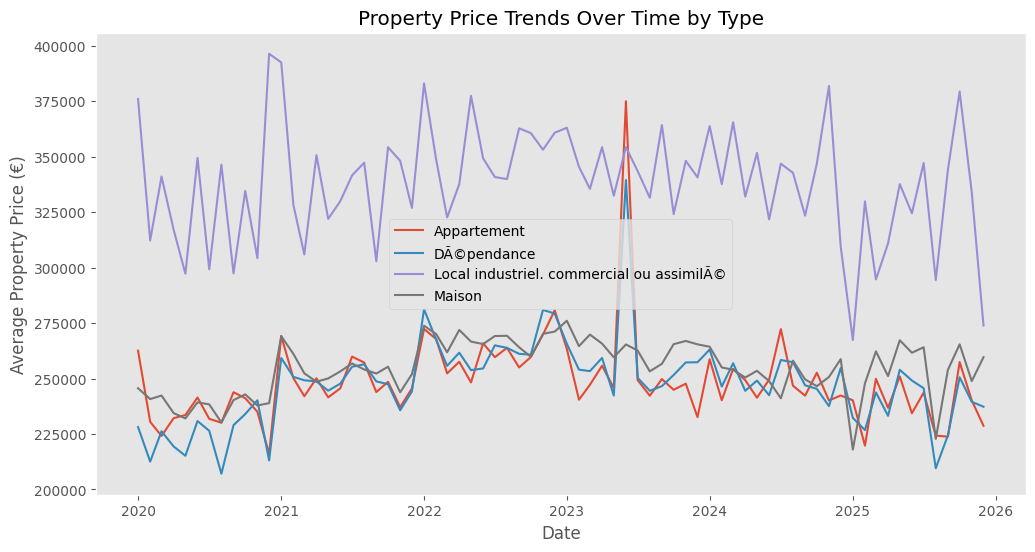

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your combined dataset
# df = pd.read_csv("../data/processed/ValeursFoncieres_all.csv")

# Convert date
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep only useful rows
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers (recommended)
df = df[df["Valeur fonciere"] < 2_000_000]

# Create year-month column
df["year_month"] = df["Date mutation"].dt.to_period("M")

# Aggregate: mean price per month per property type
df_grouped = df.groupby(["year_month", "Type local"])["Valeur fonciere"].mean().reset_index()

# Convert back to timestamp for plotting
df_grouped["year_month"] = df_grouped["year_month"].dt.to_timestamp()

# Plot
plt.figure(figsize=(12, 6))

for property_type in df_grouped["Type local"].unique():
    subset = df_grouped[df_grouped["Type local"] == property_type]
    plt.plot(subset["year_month"], subset["Valeur fonciere"], label=property_type)

plt.xlabel("Date")
plt.ylabel("Average Property Price (€)")
plt.title("Property Price Trends Over Time by Type")
plt.legend()
plt.grid()

plt.show()

**PLOT : Linear chart 2020-2025 PROPERTY_TYPE/PRICE TRENDS (price per m²)**

to clearly see:
- 📈 Market growth over 5–6 years
- 🏠 Difference between houses vs apartments
- 📉 Market dips (e.g., COVID effects)

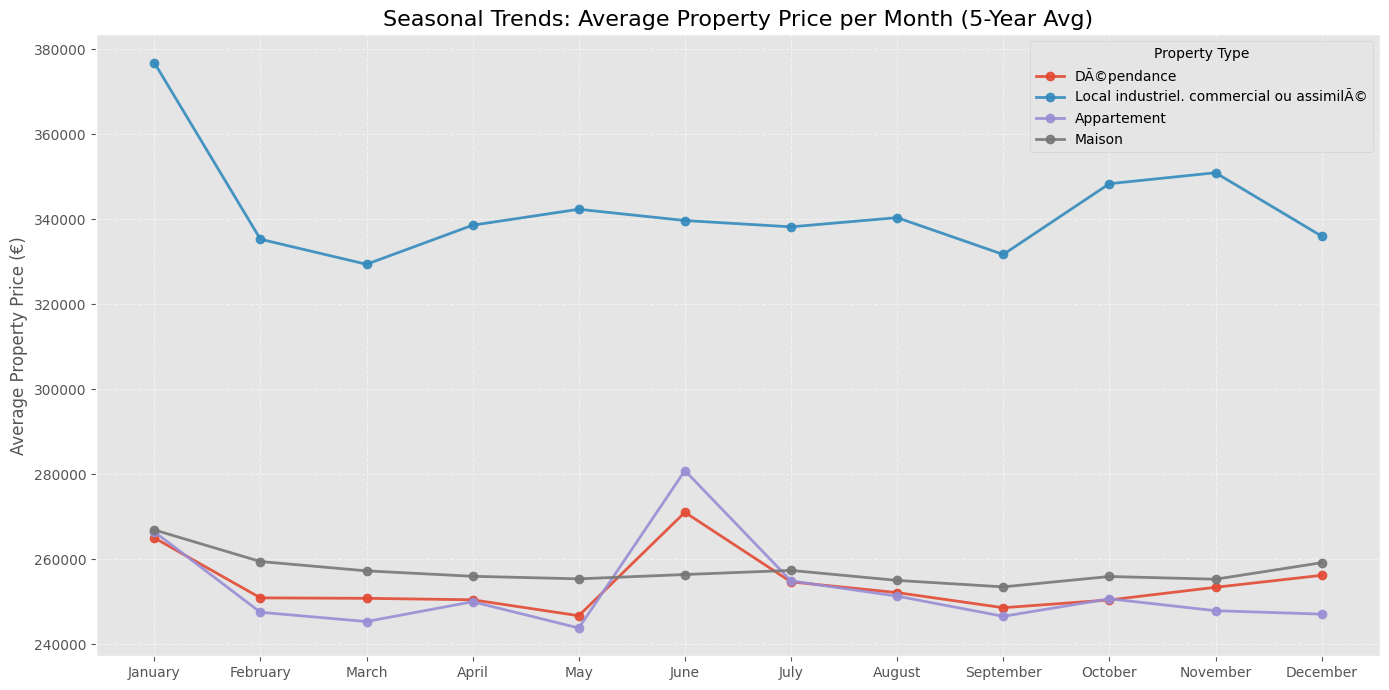

Monthly averages across 5 years:
Type local  Appartement  DÃ©pendance  \
Month_Name                             
January        266449.0     265015.0   
February       247497.0     250887.0   
March          245315.0     250781.0   
April          249979.0     250435.0   
May            243792.0     246682.0   
June           280849.0     271031.0   
July           254879.0     254650.0   
August         251298.0     252130.0   
September      246545.0     248569.0   
October        250666.0     250399.0   
November       247866.0     253379.0   
December       247065.0     256194.0   

Type local  Local industriel. commercial ou assimilÃ©    Maison  
Month_Name                                                       
January                                      376903.0  266889.0  
February                                     335323.0  259443.0  
March                                        329423.0  257244.0  
April                                        338628.0  255971.0  
May       

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your combined DVF dataset
#df = pd.read_csv("../data/processed/ValeursFoncieres_all.csv")

# Convert date column
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep only relevant columns and drop missing
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers
df = df[df["Valeur fonciere"] < 2_000_000]

# Extract month name
df['Month_Name'] = df['Date mutation'].dt.month_name()

# Calculate average price per month for each Type local
monthly_avg = df.groupby(['Type local', 'Month_Name'])['Valeur fonciere'].mean().reset_index()

# Define month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Sort by month order
monthly_avg['Month_Name'] = pd.Categorical(monthly_avg['Month_Name'], categories=month_order, ordered=True)
monthly_avg = monthly_avg.sort_values('Month_Name')

# Plot
plt.figure(figsize=(14,7))
for property_type in monthly_avg['Type local'].unique():
    subset = monthly_avg[monthly_avg['Type local'] == property_type]
    plt.plot(subset['Month_Name'], subset['Valeur fonciere'],
             marker='o', linewidth=2, alpha=0.9, label=property_type)

plt.title("Seasonal Trends: Average Property Price per Month (5-Year Avg)", fontsize=16)
plt.ylabel("Average Property Price (€)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Property Type")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Optional: print the monthly averages table
print("Monthly averages across 5 years:")
print(monthly_avg.pivot(index='Month_Name', columns='Type local', values='Valeur fonciere').round(0))

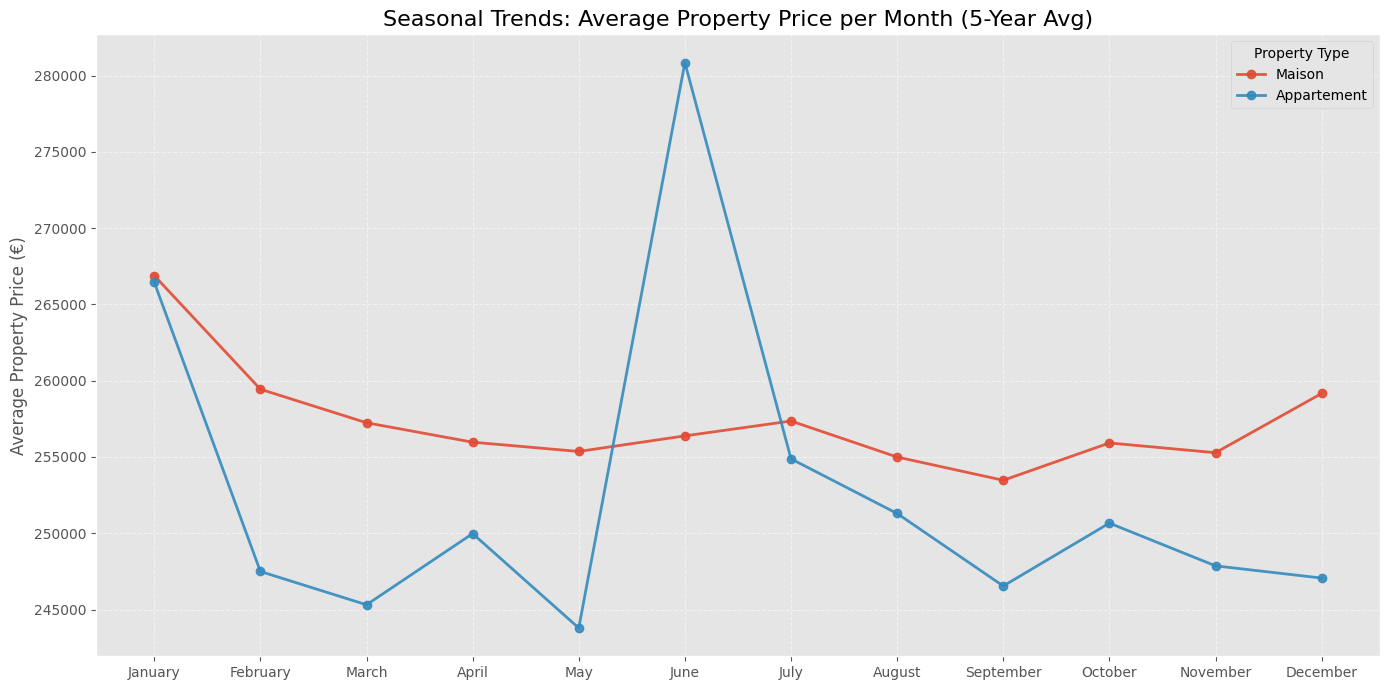

Monthly averages across 5 years (Maison & Appartement):
Type local  Appartement    Maison
Month_Name                       
January        266449.0  266889.0
February       247497.0  259443.0
March          245315.0  257244.0
April          249979.0  255971.0
May            243792.0  255363.0
June           280849.0  256385.0
July           254879.0  257358.0
August         251298.0  254998.0
September      246545.0  253474.0
October        250666.0  255920.0
November       247866.0  255282.0
December       247065.0  259165.0


In [10]:
import pandas as pd
import matplotlib.pyplot as plt


# Convert date column
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep only relevant columns and drop missing
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers
df = df[df["Valeur fonciere"] < 2_000_000]

# Filter only Maison and Appartement
df = df[df["Type local"].isin(["Maison", "Appartement"])]

# Extract month name
df['Month_Name'] = df['Date mutation'].dt.month_name()

# Calculate average price per month for each Type local
monthly_avg = df.groupby(['Type local', 'Month_Name'])['Valeur fonciere'].mean().reset_index()

# Define month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Sort by month order
monthly_avg['Month_Name'] = pd.Categorical(monthly_avg['Month_Name'], categories=month_order, ordered=True)
monthly_avg = monthly_avg.sort_values('Month_Name')

# Plot
plt.figure(figsize=(14,7))
for property_type in ["Maison", "Appartement"]:
    subset = monthly_avg[monthly_avg['Type local'] == property_type]
    plt.plot(subset['Month_Name'], subset['Valeur fonciere'],
             marker='o', linewidth=2, alpha=0.9, label=property_type)

plt.title("Seasonal Trends: Average Property Price per Month (5-Year Avg)", fontsize=16)
plt.ylabel("Average Property Price (€)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Property Type")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Optional: print the monthly averages table
print("Monthly averages across 5 years (Maison & Appartement):")
print(monthly_avg.pivot(index='Month_Name', columns='Type local', values='Valeur fonciere').round(0))

In [11]:
import pandas as pd
import plotly.graph_objects as go

# Load DVF dataset
df = pd.read_csv("../data/processed/ValeursFoncieres_all.csv")

# Convert date
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep relevant columns and drop missing
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers
df = df[df["Valeur fonciere"] < 2_000_000]

# Filter only Maison & Appartement
df = df[df["Type local"].isin(["Maison", "Appartement"])]

# Extract month names and short names
full_to_short = {
    'January': 'Jan', 'February': 'Feb', 'March': 'Mar', 'April': 'Apr',
    'May': 'May', 'June': 'Jun', 'July': 'Jul', 'August': 'Aug',
    'September': 'Sep', 'October': 'Oct', 'November': 'Nov', 'December': 'Dec'
}
df['Month_Name'] = df['Date mutation'].dt.month_name()
df['Month_Short'] = df['Month_Name'].map(full_to_short)

# Define month order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Compute 5-year monthly averages per property type
monthly_data = {}
for prop_type in ["Maison", "Appartement"]:
    monthly_avg = df[df["Type local"] == prop_type].groupby("Month_Short")["Valeur fonciere"].mean().reset_index()
    monthly_avg['Month_Short'] = pd.Categorical(monthly_avg['Month_Short'], categories=month_order, ordered=True)
    monthly_avg = monthly_avg.sort_values("Month_Short")
    monthly_data[prop_type] = monthly_avg.set_index("Month_Short")["Valeur fonciere"]

# Combine into DataFrame
monthly_df = pd.DataFrame(monthly_data).reindex(month_order)

# Colors for the two types
colors = ['#4C78A8', '#F58518']  # Maison = blue, Appartement = orange

# Plotly figure
fig = go.Figure()
for i, prop_type in enumerate(["Maison", "Appartement"]):
    fig.add_trace(go.Scatter(
        x=monthly_df.index,
        y=monthly_df[prop_type],
        mode='lines+markers',
        name=prop_type,
        line=dict(color=colors[i], width=3),
        marker=dict(size=8),
        hovertemplate=f'<b>{prop_type}</b><br>Month: %{{x}}<br>Avg Price: €%{{y:,.0f}}<extra></extra>'
    ))

fig.update_layout(
    title='Property Price Trends - Seasonal 5-Year Monthly Averages',
    xaxis_title="",
    yaxis_title="Average Property Price (€)",
    hovermode='x unified',
    legend=dict(title="Property Type", yanchor="top", y=1.0, xanchor="left", x=1.02),
    width=1200,
    height=600,
    plot_bgcolor='white',
    font=dict(size=12)
)

fig.update_xaxes(tickangle=0)
fig.update_yaxes(gridcolor='lightgray')

fig.show()

# Optional: print monthly averages table
print("✅ Seasonal 5-Year Monthly Averages (Maison & Appartement):")
print(monthly_df.round(0))

✅ Seasonal 5-Year Monthly Averages (Maison & Appartement):
               Maison  Appartement
Month_Short                       
Jan          266889.0     266449.0
Feb          259443.0     247497.0
Mar          257244.0     245315.0
Apr          255971.0     249979.0
May          255363.0     243792.0
Jun          256385.0     280849.0
Jul          257358.0     254879.0
Aug          254998.0     251298.0
Sep          253474.0     246545.0
Oct          255920.0     250666.0
Nov          255282.0     247866.0
Dec          259165.0     247065.0


<hr>

## 2 - DATA LOADING & EXPLORATION


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

In [ ]:
import pandas as pd

# Read arrondissements
df_arrondissements = pd.read_csv("../data/raw/arrondissements.csv", sep=";")
print("RAW DATA: Arrondissements:")
display(df_arrondissements.head())

# Select columns for ERD
arrondissements = df_arrondissements[[
    "Numéro d'arrondissement INSEE", 
    "Nom officiel de l'arrondissement", 
    "Surface", 
    "Périmètre", 
    "Geometry X Y"
]]

# Split Geometry X Y into Latitude and Longitude
arrondissements[['Latitude', 'Longitude']] = arrondissements['Geometry X Y']\
    .str.split(',', expand=True)

# Remove extra whitespace and convert to float
arrondissements['Latitude'] = arrondissements['Latitude'].str.strip().astype(float)
arrondissements['Longitude'] = arrondissements['Longitude'].str.strip().astype(float)

# Drop original column
arrondissements.drop(columns=['Geometry X Y'], inplace=True)

# Preview and save
display(arrondissements.head())
print("CLEAN DATA: Arrondissements:")
print(arrondissements.shape[0], "rows and", arrondissements.shape[1], "columns")
arrondissements.to_csv("../data/processed/clean_arrondissements.csv", index=False)

RAW DATA: Arrondissements:


,Identifiant séquentiel de l’arrondissement,Numéro d’arrondissement,Numéro d’arrondissement INSEE,Nom de l’arrondissement,Nom officiel de l’arrondissement,N_SQ_CO,Surface,Périmètre,Geometry X Y,Geometry
0,750000017,17,75117,17ème Ardt,Batignolles-Monceau,750001537,5.668835e+06,10775.579516,"48.887326522025816, 2.3067769905744084","{""coordinates"": [[[2.295166912564455, 48.87395..."
1,750000006,6,75106,6ème Ardt,Luxembourg,750001537,2.153096e+06,6483.686786,"48.84913035858523, 2.3328979990533147","{""coordinates"": [[[2.3445926774963546, 48.8540..."
2,750000015,15,75115,15ème Ardt,Vaugirard,750001537,8.494994e+06,13678.798315,"48.840085375938216, 2.2928258224249976","{""coordinates"": [[[2.2993223102646487, 48.8521..."
3,750000002,2,75102,2ème Ardt,Bourse,750001537,9.911537e+05,4554.104360,"48.86827922252251, 2.3428025468913636","{""coordinates"": [[[2.3515184836708216, 48.8644..."
4,750000008,8,75108,8ème Ardt,Élysée,750001537,3.880036e+06,7880.533268,"48.872720837434464, 2.312554022402065","{""coordinates"": [[[2.325836254471965, 48.86956..."


C:\Users\sboub\AppData\Local\Temp\ipykernel_6164\584742645.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  arrondissements[['Latitude', 'Longitude']] = arrondissements['Geometry X Y']\
C:\Users\sboub\AppData\Local\Temp\ipykernel_6164\584742645.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  arrondissements[['Latitude', 'Longitude']] = arrondissements['Geometry X Y']\
C:\Users\sboub\AppData\Local\Temp\ipykernel_6164\584742645.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

,Numéro d’arrondissement INSEE,Nom officiel de l’arrondissement,Surface,Périmètre,Latitude,Longitude
0,75117,Batignolles-Monceau,5.668835e+06,10775.579516,48.887327,2.306777
1,75106,Luxembourg,2.153096e+06,6483.686786,48.849130,2.332898
2,75115,Vaugirard,8.494994e+06,13678.798315,48.840085,2.292826
3,75102,Bourse,9.911537e+05,4554.104360,48.868279,2.342803
4,75108,Élysée,3.880036e+06,7880.533268,48.872721,2.312554


CLEAN DATA: Arrondissements:
20 rows and 6 columns


In [16]:
# COMMUNE DATA
df_communes = pd.read_csv("../data/raw/etablissements-adultes-handicap.csv", sep=";")
print("Communes:")
display(df_communes.head(3))
df_communes.info()
    

Communes:


,NOM,TYPE,ADRESSE,CP,COMMUNE,CODE_INSEE,TEL,CAPACITE,ACCUEIL TEMP,SUPERPOSITION,geo_shape,geo_point_2d
0,FAM Perce-Neige,Foyer d'accueil médicalisé,3 PASSAGE THUILLIER,92400,COURBEVOIE,92026,01.47.68.30.10,27,0,NON,"{""coordinates"": [2.2546608584721413, 48.900903...","48.90090342579712, 2.2546608584721413"
1,Foyer de vie Jean Jaurès,Foyer de vie,19 BIS RUE JEAN JAURES,92230,GENNEVILLIERS,92036,01.47.21.40.17,25,0,NON,"{""coordinates"": [2.2949038872049, 48.931711125...","48.93171112541918, 2.2949038872049"
2,FAM Villebois-Mareuil,Foyer d'accueil médicalisé,62 RUE VILLEBOIS MAREUIL,92230,GENNEVILLIERS,92036,01.41.47.20.95,32,0,NON,"{""coordinates"": [2.3011646312148453, 48.934813...","48.93481376128417, 2.3011646312148453"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   NOM            130 non-null    object
 1   TYPE           130 non-null    object
 2   ADRESSE        130 non-null    object
 3   CP             130 non-null    int64 
 4   COMMUNE        130 non-null    object
 5   CODE_INSEE     130 non-null    int64 
 6   TEL            130 non-null    object
 7   CAPACITE       130 non-null    int64 
 8   ACCUEIL TEMP   130 non-null    int64 
 9   SUPERPOSITION  130 non-null    object
 10  geo_shape      130 non-null    object
 11  geo_point_2d   130 non-null    object
dtypes: int64(4), object(8)
memory usage: 12.3+ KB


In [ ]:
import pandas as pd

# RESIDENCES UNIVERSITAIRES
df_residences_universitaires = pd.read_csv("../data/raw/residences-universitaires-crous-en-ile-de-france.csv", sep=";")
print("Résidences Universitaires:")
display(df_residences_universitaires.head(3))

# drop 
'''
virtualVisitUrl
crousAndGoUrl
albumUrl
bookingUrl
troubleshootingUrl
coord_gps
'''

residences_universitaires = df_residences_universitaires.drop(columns=[
    "virtualVisitUrl",
    "crousAndGoUrl",
    "albumUrl",
    "bookingUrl",
    "troubleshootingUrl",
    "coord_gps"
])

print("CLEAN DATA: Résidences Universitaires:")
display(residences_universitaires.head(3))
#print(residences_universitaires.shape[0], "rows and", residences_universitaires.shape[1], "columns")

Résidences Universitaires:


,id,Académie,title,short_desc,lat,lon,zone,infos,services,contact,address,mail,phone,openingHours,internetUrl,appointmentUrl,virtualVisitUrl,crousAndGoUrl,albumUrl,bookingUrl,troubleshootingUrl,house_services,images,coord_gps,services_residence
0,1130,Paris,Résidence Grands Moulins,Résidence située à proximité de la Bibliothèqu...,48.827599,2.37644,Paris 13,"<p><img src=""http://www.crous-paris.fr/wp-cont...",Contrôle d'accès\nParking payant\nLocal à vélo...,"<p><![CDATA[</p>\r\n<div class=""EncartVert"">\r...",54-56 rue des Grands Moulins 75013 Paris,chevaleret@crous-paris.fr,NaN,<p>9h à 12h30<br />13h30 à 16h</p>,https://www.crous-paris.fr/,https://www.crous-paris.fr/,NaN,NaN,NaN,https://www.crous-paris.fr/logements/demander-...,https://www.crous-paris.fr/,"{""house_service"": [""Accessible PMR"", ""Ascenseu...","{""url"": [""https://admin-v2.crous-mobile.fr//me...","48.8275985718, 2.3764400482",<ul><li>Accessible PMR</li><li>Ascenseur</li><...
1,1147,Paris,Résidence Bessières,NaN,48.897301,2.32591,Paris 17,"<p><img src=""http://www.crous-paris.fr/wp-cont...",- Contrôle d'accès \r\n - Local à vélos \r\n -...,"<p><![CDATA[</p>\r\n<div class=""EncartVert"">\r...",27 boulevard Bessières 75017 Paris,croisset@crous-paris.fr,01 40 51 35 47,"<div class=""Encart""><strong>Accueil et renseig...",https://www.crous-paris.fr/,https://www.crous-paris.fr/,NaN,NaN,NaN,https://www.crous-paris.fr/logements/demander-...,https://www.crous-paris.fr/,"{""house_service"": [""Accessible PMR"", ""Garage à...","{""url"": [""https://admin-v2.crous-mobile.fr//me...","48.8973007202, 2.3259100914",<ul><li>Accessible PMR</li><li>Garage à vélos<...
2,1213,Paris,Résidence Championnet 2,NaN,48.895219,2.35258,Paris 18,<p><strong>Adresse de la résidence :</strong> ...,Contrôle d’accès\nLocal à vélos\nAccès Interne...,<p><strong>Résidence Championnet 2</strong></p...,2 rue Championnet 75018 Paris,poissonniers@crous-paris.fr,01 40 51 37 75,NaN,https://www.crous-paris.fr/,https://www.crous-paris.fr/,NaN,NaN,NaN,https://www.crous-paris.fr/logements/demander-...,https://www.crous-paris.fr/,"{""house_service"": [""Accessible PMR"", ""Ascenseu...","{""url"": [""https://admin-v2.crous-mobile.fr//me...","48.8952186, 2.35258",<ul><li>Accessible PMR</li><li>Ascenseur</li><...


### STATUS D'OCCUPATION des RESIDENCES PRINCIPALES

In [12]:
# STATUS D'OCCUPATION des RESIDENCES PRINCIPALES
df_statuts_occupation = pd.read_csv("../data/raw/statuts-doccupation-des-residences-principales-des-communes-donnee-insee.csv", sep=";")
print("Statuts d'occupation des résidences principales:")
display(df_statuts_occupation.head())

Statuts d'occupation des résidences principales:


,Geo Point,Geo Shape,insee,propri,loc_prive,loc_hlm,loge_grat,objectid,loc_meuble
0,"48.3487428126, 2.56411763357","{""coordinates"": [2.564117633568488, 48.3487428...",77001,413.899704,27.570390,0.000000,15.365497,6,5.164409
1,"48.8432766256, 2.81653798016","{""coordinates"": [2.816537980161528, 48.8432766...",77018,1589.639610,445.547249,414.490793,25.076784,65,299.245565
2,"48.7736559886, 1.85178491669","{""coordinates"": [1.851784916691507, 48.7736559...",78050,211.000000,19.000000,0.000000,8.000000,79,0.000000
3,"48.6758272988, 2.04925351361","{""coordinates"": [2.049253513605204, 48.6758272...",91093,216.000000,12.000000,0.000000,4.000000,141,1.000000
4,"48.791668334, 2.33207260764","{""coordinates"": [2.332072607638279, 48.7916683...",94016,5193.592683,2562.411729,3775.432773,296.528775,188,1685.252539


### LIGNES DE TRANSPORT EN COMMUN

In [ ]:
# LIGNES DE TRANSPORT EN COMMUN
df_lignes_transport = pd.read_csv("../data/raw/traces-des-lignes-de-transport-en-commun-idfm.csv", sep=";")
print("Lignes de transport en commun:")
display(df_lignes_transport.head())

Lignes de transport en commun:


,ID,Short Name,Long Name,Route Type,Color,Route URL,Shape,id_ilico,OperatorName,NetworkName,ID_Bus_Contrat,url,Type,long_name_first,geo_point_2d
0,IDFM:C00029,502,502,Bus,FBE324,NaN,"{""coordinates"": [[[2.605063, 48.801975], [2.60...",C00029,Keolis Grand Paris Vallée de la Marne,Marne et Brie,9.0,https://ilico.iledefrance-mobilites.fr/uploads...,HORAIRE|PLAN,5,"48.78188816972777, 2.6480891283837553"
1,IDFM:C01094,57,57,Bus,6E6E00,NaN,"{""coordinates"": [[[2.409755, 48.863434], [2.41...",C01094,RATP,NaN,NaN,https://www.ratp.fr/sites/default/files/lines-...,HORAIRE|PLAN,5,"48.83515885931267, 2.3687425840691674"
2,IDFM:C02220,Soir,Soir Mennecy,Bus,640082,NaN,NaN,C02220,Keolis Val d'Essonne Deux Vallées,Essonne Sud Est,31.0,https://ilico.iledefrance-mobilites.fr/uploads...,HORAIRE|PLAN,S,NaN
3,IDFM:C00527,6183,6183,Bus,640082,NaN,"{""coordinates"": [[[2.037603, 48.707024], [2.03...",C00527,Keolis Vélizy Vallée de la Bièvre,Vélizy Vallées,27.0,https://ilico.iledefrance-mobilites.fr/uploads...,HORAIRE|PLAN,6,"48.72894729625489, 2.0909603606050835"
4,IDFM:C02301,GPSO Bus,GPSO Bus,Bus,FF9900,NaN,"{""coordinates"": [[[2.182615, 48.825516], [2.18...",C02301,Origami / Mobicité,Grand Paris Seine Ouest,NaN,https://ilico.iledefrance-mobilites.fr/uploads...,HORAIRE|PLAN,G,"48.81986189913045, 2.1925887330951395"


### DVF 2020-2025

In [1]:
import pandas as pd

# DVF DATA 2020_S2 - 2025_S1
# the files are separated by pipe and tab, so must specify both as separators
df_valeurs_foncieres_2020 = pd.read_csv("../data/raw/ValeursFoncieres-2020-S2.txt", sep="|",low_memory=True)
df_valeurs_foncieres_2021 = pd.read_csv("../data/raw/ValeursFoncieres-2021.txt", sep="|", low_memory=True)
df_valeurs_foncieres_2022 = pd.read_csv("../data/raw/ValeursFoncieres-2022.txt", sep="|", low_memory=True)
df_valeurs_foncieres_2023 = pd.read_csv("../data/raw/ValeursFoncieres-2023.txt", sep="|", low_memory=True)
df_valeurs_foncieres_2024 = pd.read_csv("../data/raw/ValeursFoncieres-2024.txt", sep="|", low_memory=True)
df_valeurs_foncieres_2025 = pd.read_csv("../data/raw/ValeursFoncieres-2025-S1.txt", sep="|", low_memory=True)

#df_valeurs_foncieres = pd.concat([df_valeurs_foncieres_2021, df_valeurs_foncieres_2022, df_valeurs_foncieres_2023, df_valeurs_foncieres_2024, df_valeurs_foncieres_2025], ignore_index=True)

# Save as CSV
#df_valeurs_foncieres.to_csv("../data/processed/ValeursFoncieres_2020-S2_2025-S1.csv", index=False)

# Display Valeurs Foncières data 2020-2025
#print("Valeurs Foncières 2020-2025:")
#display(df_valeurs_foncieres.head())

display(df_valeurs_foncieres_2020.head())

C:\Users\sboub\AppData\Local\Temp\ipykernel_20372\922719674.py:5: DtypeWarning: Columns (14,18,23,24,26,28,31,33,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df_valeurs_foncieres_2020 = pd.read_csv("../data/raw/ValeursFoncieres-2020-S2.txt", sep="|",low_memory=True)
C:\Users\sboub\AppData\Local\Temp\ipykernel_20372\922719674.py:6: DtypeWarning: Columns (18,23,24,26,28,29,30,31,33,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df_valeurs_foncieres_2021 = pd.read_csv("../data/raw/ValeursFoncieres-2021.txt", sep="|", low_memory=True)
C:\Users\sboub\AppData\Local\Temp\ipykernel_20372\922719674.py:7: DtypeWarning: Columns (18,23,24,26,28,29,31,33,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df_valeurs_foncieres_2022 = pd.read_csv("../data/raw/ValeursFoncieres-2022.txt", sep="|", low_memory=True)
C:\Users\sboub\AppData\Local\Temp\ipykernel_20372\922719674.py:8: DtypeWarning: Columns (14,18,

MemoryError: Unable to allocate 612. MiB for an array with shape (23, 3489149) and data type object

In [20]:
import pandas as pd

files = [
    "../data/raw/ValeursFoncieres-2020-S2.txt",
    "../data/raw/ValeursFoncieres-2021.txt",
    "../data/raw/ValeursFoncieres-2022.txt",
    "../data/raw/ValeursFoncieres-2023.txt",
    "../data/raw/ValeursFoncieres-2024.txt",
    "../data/raw/ValeursFoncieres-2025-S1.txt",
]

output_file = "../data/processed/ValeursFoncieres_2020-S2_2025-S1.csv"
chunksize = 50_000  # 1 million rows per chunk; adjust if needed

# If writing CSV incrementally, first remove existing file
import os
if os.path.exists(output_file):
    os.remove(output_file)

for i, file in enumerate(files):
    print(f"Processing {file} ...")
    
    # Optional: add year info
    year = file.split('-')[-1].replace('.txt','')
    
    # Read in chunks
    for chunk in pd.read_csv(file, sep="|", chunksize=chunksize, low_memory=True):
        # Append to CSV (write header only for the first chunk)
        chunk.to_csv(output_file, mode='a', index=False, header=not os.path.exists(output_file))

print("All files processed and saved!")

Processing ../data/raw/ValeursFoncieres-2020-S2.txt ...


C:\Users\sboub\AppData\Local\Temp\ipykernel_20372\771675893.py:27: DtypeWarning: Columns (23,24,26,29,31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file, sep="|", chunksize=chunksize, low_memory=True):
C:\Users\sboub\AppData\Local\Temp\ipykernel_20372\771675893.py:27: DtypeWarning: Columns (24,26,28,29,31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file, sep="|", chunksize=chunksize, low_memory=True):
C:\Users\sboub\AppData\Local\Temp\ipykernel_20372\771675893.py:27: DtypeWarning: Columns (31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file, sep="|", chunksize=chunksize, low_memory=True):
C:\Users\sboub\AppData\Local\Temp\ipykernel_20372\771675893.py:27: DtypeWarning: Columns (23,24,29,31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file, sep="|"

Processing ../data/raw/ValeursFoncieres-2021.txt ...


C:\Users\sboub\AppData\Local\Temp\ipykernel_20372\771675893.py:27: DtypeWarning: Columns (24,29,31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file, sep="|", chunksize=chunksize, low_memory=True):
C:\Users\sboub\AppData\Local\Temp\ipykernel_20372\771675893.py:27: DtypeWarning: Columns (23,24,26,28,29,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file, sep="|", chunksize=chunksize, low_memory=True):
C:\Users\sboub\AppData\Local\Temp\ipykernel_20372\771675893.py:27: DtypeWarning: Columns (24,26,31,41) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file, sep="|", chunksize=chunksize, low_memory=True):
C:\Users\sboub\AppData\Local\Temp\ipykernel_20372\771675893.py:27: DtypeWarning: Columns (24,26,28,29,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file, sep=

MemoryError: Unable to allocate 5.11 MiB for an array with shape (18, 2325) and data type <U32

In [ ]:
import pandas as pd

# Path to your large CSV file
file_path = '../data/raw/ValeursFoncieres-2020-S2.txt'

# Create an empty list to store processed chunks (optional)
chunks = []

# Define chunk size (number of rows per chunk)
chunk_size = 100000  # adjust based on your RAM

# Read the CSV in chunks
for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    # Optional: process the chunk here, e.g., filter columns, rows
    # chunk = chunk[['column1', 'column2']]  # select columns
    # chunk = chunk[chunk['column3'] > 0]    # filter rows

    # Append to list (if you want to combine later)
    chunks.append(chunk)

# Combine all processed chunks into one DataFrame (if needed)
df = pd.concat(chunks, ignore_index=True)

# Now df contains your data, processed in a memory-efficient way
print(df.head())

In [24]:
import csv

input_file = '../data/raw/ValeursFoncieres-2020-S2.txt'
output_file = '../data/processed/ValeursFoncieres-2020-S2-clean.csv'

# Column names from the header
columns = ["Identifiant de document","Reference document","1 Articles CGI","2 Articles CGI",
           "3 Articles CGI","4 Articles CGI","5 Articles CGI","No disposition","Date mutation",
           "Nature mutation","Valeur fonciere","No voie","B/T/Q","Type de voie","Code voie",
           "Voie","Code postal","Commune","Code departement","Code commune","Prefixe de section",
           "Section","No plan","No Volume","1er lot","Surface Carrez du 1er lot","2eme lot",
           "Surface Carrez du 2eme lot","3eme lot","Surface Carrez du 3eme lot","4eme lot",
           "Surface Carrez du 4eme lot","5eme lot","Surface Carrez du 5eme lot","Nombre de lots",
           "Code type local","Type local","Identifiant local","Surface reelle bati",
           "Nombre pieces principales","Nature culture","Nature culture speciale","Surface terrain"]

# Open input TXT and output CSV
with open(input_file, 'r', encoding='utf-8') as f_in, \
     open(output_file, 'w', newline='', encoding='utf-8') as f_out:

    writer = csv.writer(f_out, delimiter='|')
    
    # Write the header to CSV
    writer.writerow(columns)

    # Skip TXT header line
    next(f_in)

    for line in f_in:
        # Split line by pipe
        parts = line.strip().split('|')

        # Fix decimal commas to dots in 'Valeur fonciere' (11th column, index 10)
        if len(parts) > 10 and parts[10]:
            parts[10] = parts[10].replace(',', '.')

        # Optional: convert other numeric fields with commas, e.g. Surface Carrez
        for idx in [25, 27, 29, 31, 33, 41]:  # indices of numeric columns
            if len(parts) > idx and parts[idx]:
                parts[idx] = parts[idx].replace(',', '.')

        # Write row to CSV
        writer.writerow(parts)

In [26]:
display(df_valeurs_foncieres_2021.head())
display(df_valeurs_foncieres_2021.columns.tolist())

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,Valeur fonciere,No voie,B/T/Q,Type de voie,Code voie,Voie,Code postal,Commune,Code departement,Code commune,Prefixe de section,Section,No plan,No Volume,1er lot,Surface Carrez du 1er lot,2eme lot,Surface Carrez du 2eme lot,3eme lot,Surface Carrez du 3eme lot,4eme lot,Surface Carrez du 4eme lot,5eme lot,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,05/01/2021,Vente,"185000,00",5080.0,NaN,CHE,0471,DE VOGELAS,1370.0,VAL-REVERMONT,1,426,312.0,ZC,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.0,Dépendance,NaN,0.0,0.0,S,NaN,2410.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,05/01/2021,Vente,"185000,00",5080.0,NaN,CHE,0471,DE VOGELAS,1370.0,VAL-REVERMONT,1,426,312.0,ZC,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,97.0,5.0,S,NaN,2410.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,06/01/2021,Vente,"10,00",NaN,NaN,NaN,B043,ROUGEMONT,1290.0,BEY,1,42,NaN,A,204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,BT,NaN,530.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,04/01/2021,Vente,"204332,00",7.0,NaN,ALL,0276,DES ECUREUILS,1310.0,BUELLAS,1,65,NaN,B,1325,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,88.0,4.0,S,NaN,866.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,06/01/2021,Vente,"320000,00",87.0,NaN,RTE,0140,DE CERTINES,1250.0,MONTAGNAT,1,254,NaN,AZ,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.0,Dépendance,NaN,0.0,0.0,S,NaN,1426.0


['Identifiant de document',
 'Reference document',
 '1 Articles CGI',
 '2 Articles CGI',
 '3 Articles CGI',
 '4 Articles CGI',
 '5 Articles CGI',
 'No disposition',
 'Date mutation',
 'Nature mutation',
 'Valeur fonciere',
 'No voie',
 'B/T/Q',
 'Type de voie',
 'Code voie',
 'Voie',
 'Code postal',
 'Commune',
 'Code departement',
 'Code commune',
 'Prefixe de section',
 'Section',
 'No plan',
 'No Volume',
 '1er lot',
 'Surface Carrez du 1er lot',
 '2eme lot',
 'Surface Carrez du 2eme lot',
 '3eme lot',
 'Surface Carrez du 3eme lot',
 '4eme lot',
 'Surface Carrez du 4eme lot',
 '5eme lot',
 'Surface Carrez du 5eme lot',
 'Nombre de lots',
 'Code type local',
 'Type local',
 'Identifiant local',
 'Surface reelle bati',
 'Nombre pieces principales',
 'Nature culture',
 'Nature culture speciale',
 'Surface terrain']

In [27]:
import csv
import os

input_file = "../data/raw/ValeursFoncieres-2020-S2.txt"
output_file = "../data/processed/clean_VF2020-S2.csv"
chunk_size = 1000  # number of lines per chunk

# Make sure the output directory exists
os.makedirs(os.path.dirname(output_file), exist_ok=True)

with open(input_file, "r", encoding="utf-8") as f_in, \
     open(output_file, "w", newline="", encoding="utf-8") as f_out:

    reader = csv.reader(f_in, delimiter="|")
    writer = csv.writer(f_out)

    chunk = []

    for i, row in enumerate(reader):
        # Fix French-style decimals (comma -> dot) in Valeur fonciere (column 10, index 9)
        if i != 0 and row[9]:  # skip header
            row[9] = row[9].replace(",", ".")

        chunk.append(row)

        if len(chunk) >= chunk_size:
            writer.writerows(chunk)
            chunk = []

    # Write remaining lines
    if chunk:
        writer.writerows(chunk)

print(f"Conversion complete! CSV saved to {output_file}")

Conversion complete! CSV saved to ../data/processed/clean_VF2020-S2.csv


In [28]:
import csv
import os

input_file = "../data/raw/ValeursFoncieres-2020-S2.txt"
output_file = "../data/processed/clean_VF2020-S2.csv"
chunk_size = 1000

os.makedirs(os.path.dirname(output_file), exist_ok=True)

with open(input_file, "r", encoding="utf-8") as f_in, \
     open(output_file, "w", newline="", encoding="utf-8") as f_out:

    reader = csv.reader(f_in, delimiter="|")
    writer = csv.writer(f_out)

    chunk = []
    for i, row in enumerate(reader):
        # Remove the first 7 columns (they are empty)
        row = row[7:]

        # Fix French-style decimal in 'Valeur fonciere' (new index 2)
        if i != 0 and row[2]:
            row[2] = row[2].replace(",", ".")

        chunk.append(row)

        if len(chunk) >= chunk_size:
            writer.writerows(chunk)
            chunk = []

    if chunk:
        writer.writerows(chunk)

print(f"Conversion complete! Clean CSV saved to {output_file}")

Conversion complete! Clean CSV saved to ../data/processed/clean_VF2020-S2.csv


In [29]:
df = pd.read_csv("../data/processed/clean_VF2020-S2.csv")

C:\Users\sboub\AppData\Local\Temp\ipykernel_20372\4100331854.py:1: DtypeWarning: Columns (7,11,16,17,19,21,24,26,34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/clean_VF2020-S2.csv")


MemoryError: Unable to allocate 15.8 MiB for an array with shape (1, 2065003) and data type int64

In [30]:
! pip install mysql-connector-python

   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
    --------------------------------------- 0.3/16.5 MB ? eta -:--:--
   - -------------------------------------- 0.5/16.5 MB 1.2 MB/s eta 0:00:14
   -- ------------------------------------- 1.0/16.5 MB 1.3 MB/s eta 0:00:12
   --- ------------------------------------ 1.3/16.5 MB 1.3 MB/s eta 0:00:12
   ---- ----------------------------------- 1.8/16.5 MB 1.6 MB/s eta 0:00:10
   ----- ---------------------------------- 2.4/16.5 MB 1.7 MB/s eta 0:00:09
   ------ --------------------------------- 2.9/16.5 MB 1.8 MB/s eta 0:00:08
   -------- ------------------------------- 3.4/16.5 MB 1.9 MB/s eta 0:00:07
   ---------- ----------------------------- 4.2/16.5 MB 2.1 MB/s eta 0:00:06
   ----------- ---------------------------- 4.7/16.5 MB 2.1 MB/s eta 0:00:06
   ------------ --------------------------- 5.0/16.5 MB 2.1 MB/s eta 0:00:06
   ------------- ---

In [ ]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="samia",
    password="ironhack13",
    database="rncp"
)

query = "SELECT * FROM valeurs_foncieres"

for chunk in pd.read_sql(query, conn, chunksize=10000):
    print(chunk.head())

conn.close()

#### COMBINING TXT FILEs

In [4]:
# List your input files from 2020 to 2025
input_files = [
    "../data/raw/DVF/data_2020.txt",
    "../data/raw/DVF/data_2021.txt",
    "../data/raw/DVF/data_2022.txt",
    "../data/raw/DVF/data_2023.txt",
    "../data/raw/DVF/data_2024.txt",
    "../data/raw/DVF/data_2025.txt"
]

output_file = "../data/processed/combined_data_2020_2025.txt"

with open(output_file, 'w', encoding='utf-8') as outfile:
    for i, fname in enumerate(input_files):
        with open(fname, 'r', encoding='utf-8') as infile:
            for j, line in enumerate(infile):
                # Skip header for all but the first file
                if i > 0 and j == 0:
                    continue
                outfile.write(line)

print(f"All files from 2020 to 2025 have been combined into {output_file}")

All files from 2020 to 2025 have been combined into ../data/processed/combined_data_2020_2025.txt


#### it combined finally!

In [5]:
import pandas as pd
# List your input files
input_files = [
    "../data/raw/DVF/data_2020.txt",
    "../data/raw/DVF/data_2021.txt",
    "../data/raw/DVF/data_2022.txt",
    "../data/raw/DVF/data_2023.txt",
    "../data/raw/DVF/data_2024.txt",
    "../data/raw/DVF/data_2025.txt"
]

output_file = "../data/processed/combined_data_2020_2025.txt"

chunk_size = 1024 * 1024 * 10  # 10 MB chunks

with open(output_file, 'wb') as outfile:
    for i, fname in enumerate(input_files):
        with open(fname, 'rb') as infile:
            if i > 0:
                # Skip header line for all but first file
                infile.readline()
            
            while True:
                chunk = infile.read(chunk_size)
                if not chunk:
                    break
                outfile.write(chunk)

print(f"Files concatenated with chunking into {output_file}")

Files concatenated with chunking into ../data/processed/combined_data_2020_2025.txt


In [6]:
import pandas as pd

# use chunking to read the combined file in a memory-efficient way
chunk_size = 100_000  # number of rows per chunk (tune this)

chunks = pd.read_csv(
    "../data/processed/combined_data_2020_2025.txt",
    sep="|",
    chunksize=chunk_size,
    low_memory=True
)

for chunk in chunks:
    # Process each chunk here
    print(chunk.shape)  # example: just checking size

C:\Users\sboub\AppData\Local\Temp\ipykernel_8200\3944057163.py:13: DtypeWarning: Columns (23,24,26,28,31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in chunks:


(100000, 43)


C:\Users\sboub\AppData\Local\Temp\ipykernel_8200\3944057163.py:13: DtypeWarning: Columns (23,24,29,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in chunks:


(100000, 43)


C:\Users\sboub\AppData\Local\Temp\ipykernel_8200\3944057163.py:13: DtypeWarning: Columns (23,24,26,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in chunks:


...

C:\Users\sboub\AppData\Local\Temp\ipykernel_8200\3944057163.py:13: DtypeWarning: Columns (31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in chunks:


(100000, 43)


C:\Users\sboub\AppData\Local\Temp\ipykernel_8200\3944057163.py:13: DtypeWarning: Columns (23,24,26,31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in chunks:


(100000, 43)
(100000, 43)
(2739, 43)


C:\Users\sboub\AppData\Local\Temp\ipykernel_8200\3944057163.py:13: DtypeWarning: Columns (14,24,26,33,41) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in chunks:


In [7]:
import pandas as pd

# use chunking to read the combined file in a memory-efficient way
chunk_size = 100_000  # number of rows per chunk (tune this)

chunks = pd.read_csv(
    "../data/processed/combined_data_2020_2025.txt",
    sep="|",
    chunksize=chunk_size,
    low_memory=True
)

for chunk in chunks:
    # Process each chunk here
    display(chunk.head())  # example: just checking size

C:\Users\sboub\AppData\Local\Temp\ipykernel_8200\1486870307.py:13: DtypeWarning: Columns (23,24,26,28,31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in chunks:


,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,Valeur fonciere,No voie,B/T/Q,Type de voie,Code voie,Voie,Code postal,Commune,Code departement,Code commune,Prefixe de section,Section,No plan,No Volume,1er lot,Surface Carrez du 1er lot,2eme lot,Surface Carrez du 2eme lot,3eme lot,Surface Carrez du 3eme lot,4eme lot,Surface Carrez du 4eme lot,5eme lot,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,01/07/2020,Vente,"31234,16",NaN,NaN,NaN,B064,SAINT JULIEN,1560.0,SAINT-JULIEN-SUR-REYSSOUZE,1,367,NaN,A,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,AB,NaN,1192.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,01/07/2020,Vente,"278000,00",NaN,NaN,NaN,B188,A LA PEROUSE,1250.0,CORVEISSIAT,1,125,NaN,C,509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,BS,NaN,10092.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,01/07/2020,Vente,"278000,00",NaN,NaN,NaN,B188,A LA PEROUSE,1250.0,CORVEISSIAT,1,125,NaN,C,510,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,L,NaN,4570.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,01/07/2020,Vente,"278000,00",NaN,NaN,NaN,B079,AUX COMMUNS,1250.0,CORVEISSIAT,1,125,NaN,ZL,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,BS,NaN,5750.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,01/07/2020,Vente,"278000,00",NaN,NaN,NaN,B033,EN COMBARNAUD,1250.0,SIMANDRE-SUR-SURAN,1,408,NaN,A,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,BT,NaN,648170.0


C:\Users\sboub\AppData\Local\Temp\ipykernel_8200\1486870307.py:13: DtypeWarning: Columns (23,24,29,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in chunks:


,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,Valeur fonciere,No voie,B/T/Q,Type de voie,Code voie,Voie,Code postal,Commune,Code departement,Code commune,Prefixe de section,Section,No plan,No Volume,1er lot,Surface Carrez du 1er lot,2eme lot,Surface Carrez du 2eme lot,3eme lot,Surface Carrez du 3eme lot,4eme lot,Surface Carrez du 4eme lot,5eme lot,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,22/12/2020,Vente,"565000,00",1445.0,NaN,CHE,0563,DES COLLES,6740.0,CHATEAUNEUF,6,38,NaN,AV,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,108.0,4.0,S,NaN,500.0
100001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,22/12/2020,Vente,"565000,00",1445.0,NaN,CHE,0563,DES COLLES,6740.0,CHATEAUNEUF,6,38,NaN,AV,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,P,NaN,506.0
100002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,11/12/2020,Vente,"838000,00",5237.0,NaN,NaN,B075,SAN PEYRE,6330.0,ROQUEFORT-LES-PINS,6,105,NaN,BI,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.0,Dépendance,NaN,0.0,0.0,S,NaN,500.0
100003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,11/12/2020,Vente,"838000,00",5237.0,NaN,NaN,B075,SAN PEYRE,6330.0,ROQUEFORT-LES-PINS,6,105,NaN,BI,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4.0,Local industriel. commercial ou assimilé,NaN,45.0,0.0,AG,NaN,2326.0
100004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,11/12/2020,Vente,"838000,00",5237.0,NaN,NaN,B075,SAN PEYRE,6330.0,ROQUEFORT-LES-PINS,6,105,NaN,BI,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4.0,Local industriel. commercial ou assimilé,NaN,45.0,0.0,S,NaN,500.0


C:\Users\sboub\AppData\Local\Temp\ipykernel_8200\1486870307.py:13: DtypeWarning: Columns (23,24,26,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in chunks:


...

C:\Users\sboub\AppData\Local\Temp\ipykernel_8200\1486870307.py:13: DtypeWarning: Columns (23,24,26,31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in chunks:


,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,Valeur fonciere,No voie,B/T/Q,Type de voie,Code voie,Voie,Code postal,Commune,Code departement,Code commune,Prefixe de section,Section,No plan,No Volume,1er lot,Surface Carrez du 1er lot,2eme lot,Surface Carrez du 2eme lot,3eme lot,Surface Carrez du 3eme lot,4eme lot,Surface Carrez du 4eme lot,5eme lot,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
19900000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,26/03/2025,Vente,"610000,00",5426.0,NaN,NaN,B100,LES IMBERTS,84220.0,GORDES,84,50,NaN,AS,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.0,Dépendance,NaN,0.0,0.0,S,NaN,25.0
19900001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,26/03/2025,Vente,"610000,00",5426.0,NaN,NaN,B100,LES IMBERTS,84220.0,GORDES,84,50,NaN,AS,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,169.0,5.0,S,NaN,25.0
19900002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,26/03/2025,Vente,"610000,00",5426.0,NaN,NaN,B100,LES IMBERTS,84220.0,GORDES,84,50,NaN,AS,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.0,Dépendance,NaN,0.0,0.0,S,NaN,25.0
19900003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,26/03/2025,Vente,"610000,00",NaN,NaN,NaN,B100,LES IMBERTS,84220.0,GORDES,84,50,NaN,AS,78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,E,BASS,80.0
19900004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,27/03/2025,Vente,"173000,00",NaN,NaN,CHE,0102,DES CADES,84740.0,VELLERON,84,142,NaN,AH,878,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,L,NaN,420.0


C:\Users\sboub\AppData\Local\Temp\ipykernel_8200\1486870307.py:13: DtypeWarning: Columns (14,24,26,33,41) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in chunks:


,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,Valeur fonciere,No voie,B/T/Q,Type de voie,Code voie,Voie,Code postal,Commune,Code departement,Code commune,Prefixe de section,Section,No plan,No Volume,1er lot,Surface Carrez du 1er lot,2eme lot,Surface Carrez du 2eme lot,3eme lot,Surface Carrez du 3eme lot,4eme lot,Surface Carrez du 4eme lot,5eme lot,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
20000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,13/01/2025,Vente en l'état futur d'achèvement,"745000,00",61.0,NaN,AV,9652,VICTOR CRESSON,92130.0,ISSY-LES-MOULINEAUX,92,40,NaN,R,14,NaN,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2.0,Appartement,NaN,82.0,4.0,NaN,NaN,NaN
20000001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,09/01/2025,Vente,"95000,00",26.0,NaN,RUE,8130,RAYMOND MARCHERON,92170.0,VANVES,92,75,NaN,N,199,NaN,28.0,"18,70",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4.0,Local industriel. commercial ou assimilé,NaN,18.0,0.0,NaN,NaN,NaN
20000002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,07/01/2025,Vente,"290000,00",5.0,NaN,ALL,6144,DES MARRONNIERS,92220.0,BAGNEUX,92,7,NaN,AS,297,NaN,2027.0,"61,75",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2.0,Appartement,NaN,61.0,3.0,NaN,NaN,NaN
20000003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,07/01/2025,Vente,"290000,00",3.0,NaN,ALL,6144,DES MARRONNIERS,92220.0,BAGNEUX,92,7,NaN,AS,297,NaN,2038.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.0,Dépendance,NaN,0.0,0.0,NaN,NaN,NaN
20000004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,08/01/2025,Vente,"20000,00",13.0,NaN,RUE,3525,DE LA FERME,92350.0,LE PLESSIS-ROBINSON,92,60,NaN,L,163,NaN,230.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.0,Dépendance,NaN,0.0,0.0,NaN,NaN,NaN


,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,Valeur fonciere,No voie,B/T/Q,Type de voie,Code voie,Voie,Code postal,Commune,Code departement,Code commune,Prefixe de section,Section,No plan,No Volume,1er lot,Surface Carrez du 1er lot,2eme lot,Surface Carrez du 2eme lot,3eme lot,Surface Carrez du 3eme lot,4eme lot,Surface Carrez du 4eme lot,5eme lot,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
20100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,15/04/2025,Vente,"1281553,40",5.0,NaN,RUE,4436.0,GUY DE MAUPASSANT,75016.0,PARIS 16,75,116,NaN,DI,75,NaN,20.0,NaN,32.0,"108,58",NaN,NaN,NaN,NaN,NaN,NaN,2,2.0,Appartement,NaN,117.0,3.0,NaN,NaN,NaN
20100001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,15/04/2025,Vente,"1281553,40",5.0,NaN,RUE,4436.0,GUY DE MAUPASSANT,75016.0,PARIS 16,75,116,NaN,DI,75,NaN,20.0,NaN,32.0,"108,58",NaN,NaN,NaN,NaN,NaN,NaN,2,3.0,Dépendance,NaN,0.0,0.0,NaN,NaN,NaN
20100002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,28/04/2025,Vente,"2333333,00",4.0,NaN,PL,1278.0,DE BRETEUIL,75015.0,PARIS 15,75,115,NaN,CW,12,NaN,11.0,NaN,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3.0,Dépendance,NaN,0.0,0.0,NaN,NaN,NaN
20100003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,28/04/2025,Vente,"2333333,00",4.0,NaN,PL,1278.0,DE BRETEUIL,75015.0,PARIS 15,75,115,NaN,CW,12,NaN,11.0,NaN,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3.0,Dépendance,NaN,0.0,0.0,NaN,NaN,NaN
20100004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,28/04/2025,Vente,"2333333,00",4.0,NaN,PL,1278.0,DE BRETEUIL,75015.0,PARIS 15,75,115,NaN,CW,12,NaN,25.0,NaN,49.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2.0,Appartement,NaN,75.0,3.0,NaN,NaN,NaN


In [ ]:
import pandas as pd

input_file = "../data/processed/combined_data_2020_2025.txt"
output_file = "../data/processed/combined_data_2020_2025.csv"

chunk_size = 100_000

chunks = pd.read_csv(
    input_file,
    sep="|",
    chunksize=chunk_size,
    low_memory=False
)

for i, chunk in enumerate(chunks):
    chunk.to_csv(
        output_file,
        mode="w" if i == 0 else "a",
        index=False,
        header=(i == 0)
    )

print("Conversion complete")

<hr>

## 3 - DATA SELECTION


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

<hr>

## 4 - DATA TRANSFORMATION TO CSV


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

<hr>

## 5 - DATA VALIDATION


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

```text
Gotta Get data validated by Sabina.
```